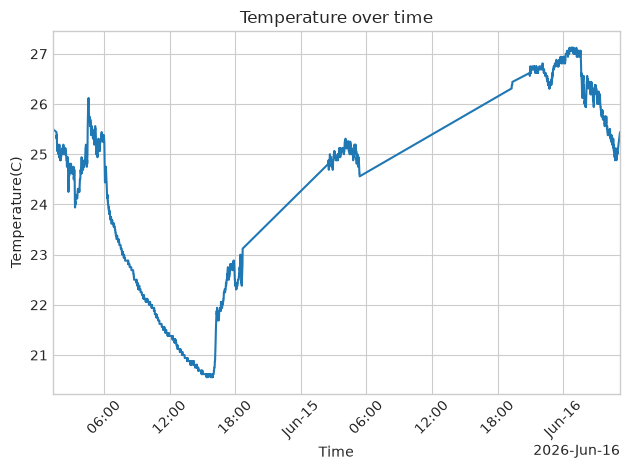

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates

#=====Config=====
INPUT_FILE = '/ros2_ws/temperature_log.csv'
OUTPUT_FILE_STEM = 'C_vs_t_graph'
OUTPUT_FILE_FOLDER = 'graphs'
#================

plt.style.use('seaborn-v0_8-whitegrid')

df = pd.read_csv(INPUT_FILE)
df.timestamp = pd.to_datetime(df.timestamp)

fig,ax = plt.subplots()

x = df.timestamp
y = df.temperature_c

ax.plot(x,y)

ax.set(
    title = 'Temperature over time',
    xlabel = 'Time',
    ylabel = 'Temperature(C)'
)

#fix time axis display
ax.tick_params(axis='x', rotation=45)
locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

plt.margins(x=0)
plt.tight_layout()

plt.show()

In [2]:
#Problem: This is actually 5-6 different temperature reading sets. The straight lines that connect them are not real. Should delete those...
#Let's make a big graph that treats the different the different data sets (separated by time jumps) as actually different.http://localhost:8888/lab?token=28de1ea0745bac39e3aeab7b7503b6476058dc26b92d2d4b


In [3]:
df.head()

,timestamp,temperature_c
0,2026-06-14 01:18:12,25.56
1,2026-06-14 01:18:42,25.56
2,2026-06-14 01:19:12,25.50
3,2026-06-14 01:38:42,25.44
4,2026-06-14 01:39:12,25.38


In [4]:
#was taking data every 30 seconds, let's isolate indices that had more than 1 min go by after the last data point.
duration = 0
indices = []
for i in range(len(df)-1):
    duration = df.timestamp.iloc[i+1]-df.timestamp.iloc[i]
    if duration.total_seconds() > 60:
        indices.append(i)
indices

[2, 2047, 2391, 2403, 3366]

In [5]:
#see if there actually was a timejump at index 2
df.head()

,timestamp,temperature_c
0,2026-06-14 01:18:12,25.56
1,2026-06-14 01:18:42,25.56
2,2026-06-14 01:19:12,25.50
3,2026-06-14 01:38:42,25.44
4,2026-06-14 01:39:12,25.38


In [6]:
(df.timestamp.iloc[3]-df.timestamp.iloc[2]).total_seconds()

1170.0

In [7]:
#split df into separate dfs for each separate time period
dfs = []
prev_cut = 0
for i in range(len(indices)):
    cut = indices[i]+1 #need to add one to include last value
    dfs.append(df.iloc[prev_cut:cut])
    prev_cut = cut
dfs[0]

,timestamp,temperature_c
0,2026-06-14 01:18:12,25.56
1,2026-06-14 01:18:42,25.56
2,2026-06-14 01:19:12,25.50


In [8]:
#see if it looks good
dfs[1]

,timestamp,temperature_c
3,2026-06-14 01:38:42,25.44
4,2026-06-14 01:39:12,25.38
5,2026-06-14 01:39:42,25.31
6,2026-06-14 01:40:12,25.38
7,2026-06-14 01:40:42,25.31
...,...,...
2043,2026-06-14 18:38:42,22.75
2044,2026-06-14 18:39:12,22.75
2045,2026-06-14 18:39:42,22.81
2046,2026-06-14 18:40:12,23.00


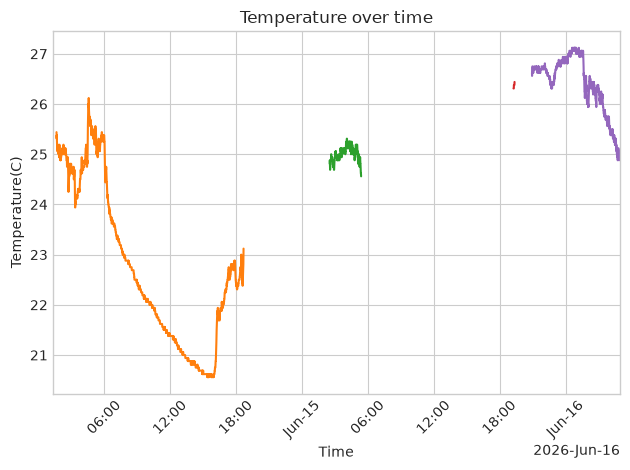

In [9]:
#graph each of the data sets on the same axes and save the figure
from datetime import datetime

fig,ax = plt.subplots()

for i in range(len(dfs)):
    ax.plot(dfs[i].timestamp, dfs[i].temperature_c)

ax.set(
    title = 'Temperature over time',
    xlabel = 'Time',
    ylabel = 'Temperature(C)'
)

#fix time axis display
ax.tick_params(axis='x', rotation=45)
locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

plt.margins(x=0)
plt.tight_layout()

#append current date & time ensure no overwriting
now = datetime.now()
file_name = OUTPUT_FILE_FOLDER + '/' + 'temperature_over_time_multiple' + '-' + now.strftime('%m-%d-%y-%H-%M-%S') + '.png'
plt.savefig(file_name)
plt.show()

In [10]:
#Let's just graph the longest dataset and save it 
longest_length = 0
longest_index = 0
for i in range(len(dfs)):
    if len(dfs[i]) > longest_length:
        longest_index = i
        longest_length = len(dfs[i])
print(longest_index, longest_length)

1 2045


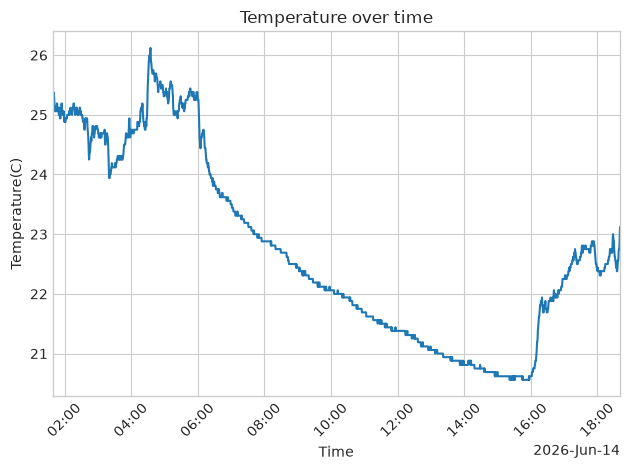

In [11]:
#graph and save
fig,ax = plt.subplots()

ax.plot(dfs[longest_index].timestamp, dfs[longest_index].temperature_c)

ax.set(
    title = 'Temperature over time',
    xlabel = 'Time',
    ylabel = 'Temperature(C)'
)

#fix time axis display
ax.tick_params(axis='x', rotation=45)
locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

plt.margins(x=0)
plt.tight_layout()

#append current date & time ensure no overwriting
now = datetime.now()
file_name = OUTPUT_FILE_FOLDER + '/' + 'temperature_over_time_longest' + '-' + now.strftime('%m-%d-%y-%H-%M-%S') + '.png'
plt.savefig(file_name)

plt.show()

<Axes: >

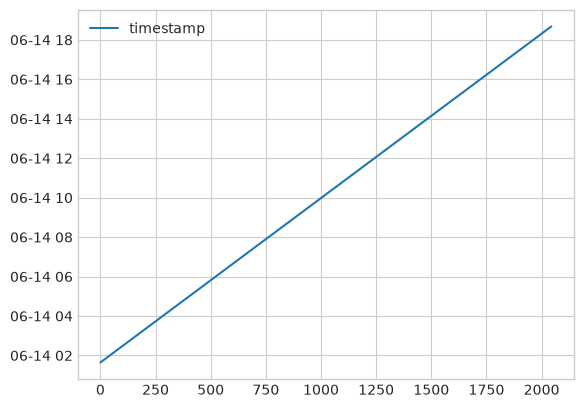

In [12]:
#I am interested in what happened at a couple of times when the temperature rapidly changed in this dataset, let's zoom in.
df_long = dfs[longest_index]
#first let's see how linear the timestamps are
df_long.reset_index(drop=True, inplace=True)
df_long.plot(y='timestamp')

In [13]:
#very consistent so we can use the different between consecutive measurements as a proxy for rate of change
consec_delta = df_long.temperature_c - df_long.shift(1).temperature_c

<Axes: >

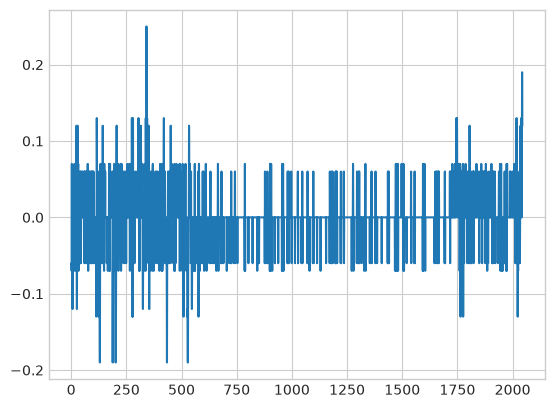

In [14]:
consec_delta.plot()

In [15]:
consec_delta.value_counts()

temperature_c
 0.00    1473
-0.06     130
 0.06     107
-0.07      75
-0.06      71
 0.07      68
 0.06      65
 0.12      11
-0.13       6
-0.12       6
 0.13       6
 0.13       5
-0.19       5
-0.12       4
-0.13       4
 0.12       3
 0.19       2
-0.19       2
 0.25       1
Name: count, dtype: int64

In [16]:
#hmm not very interesting. I think what would be better is cumulative temperature change over 10 min --> 20 data entries
ten_min_delta = df_long.temperature_c - df_long.shift(20).temperature_c
ten_min_delta.dropna(inplace=True)
print(ten_min_delta.describe())
print(ten_min_delta.sort_values())

count    2025.000000
mean       -0.025363
std         0.214582
min        -0.870000
25%        -0.070000
50%        -0.060000
75%         0.000000
max         1.370000
Name: temperature_c, dtype: float64
533   -0.87
532   -0.81
531   -0.75
534   -0.75
207   -0.75
       ... 
350    1.13
349    1.19
351    1.25
353    1.25
352    1.37
Name: temperature_c, Length: 2025, dtype: float64


In [17]:
#let's make some graphs to put on subplots, half to include the fastest increase in temperature over 10 min, half to include fastest decrease in temperature over 10 min

In [18]:
#function to get range of indicies to include in each graph. Returns list of indicies for which the 10min out increase/decrease streak maintains. 
#input series should be 10 min out changes
def extract_full_change(start_index, series): 
    if start_index not in series.index:
        return []
    if series[start_index] > 0:
        increasing = 1
    else:
        increasing = -1
    indices = [start_index]
    index = start_index
    #go forward
    while series[index] * increasing > 0:
        if index+1 not in series.index:
            break
        else:
            index= index + 1
            indices.append(index)
    index = start_index
    #go backward
    while series[index] * increasing > 0:
        if index-1 not in series.index:
            break
        else:
            index= index - 1
            indices.append(index)
    return sorted(indices)

In [19]:
#function to call extract_full_change a specified number of times to get the indices to graph for biggest changes.
def top_changes(series, number_of_changes, increasing = True):
    if len(series)== 0:
        print('Error: Series cannot be empty')
        return []
    if increasing == True:
        temp_series = series.sort_values(ascending=True)
    else:
        temp_series = series.sort_values(ascending=False)
    changes = []
    for i in range(number_of_changes):
        indices = extract_full_change(int(temp_series.index[-1]), temp_series) #first index is the start_index after sort
        changes.append(indices)
        temp_series = temp_series.drop(indices) #drop the indices found to find new changes the next time
        if len(temp_series) == 0:
            break
        i+=1
    #just want the starting and ending indices, let's cut the middle ones and subtract 20 from first index to give leadup to change (if possible)
    start_end = [[max(0,sublist[0]-20),sublist[-1]] for sublist in changes]
    return start_end

In [20]:
num_changes = 4
#get top _ increasing times/indices
to_plot_inc = top_changes(ten_min_delta, num_changes, True)
#get top _ decreasing times/indices
to_plot_dec = top_changes(ten_min_delta, num_changes, False)

<Axes: xlabel='timestamp'>

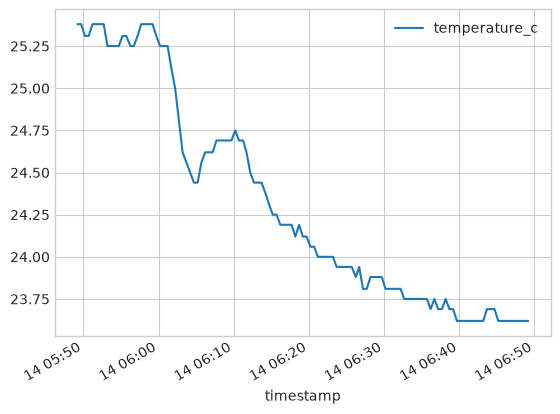

In [21]:
#does it look like it's working?
df_long.iloc[to_plot_dec[0][0]:to_plot_dec[0][1]].plot(x='timestamp',y='temperature_c')

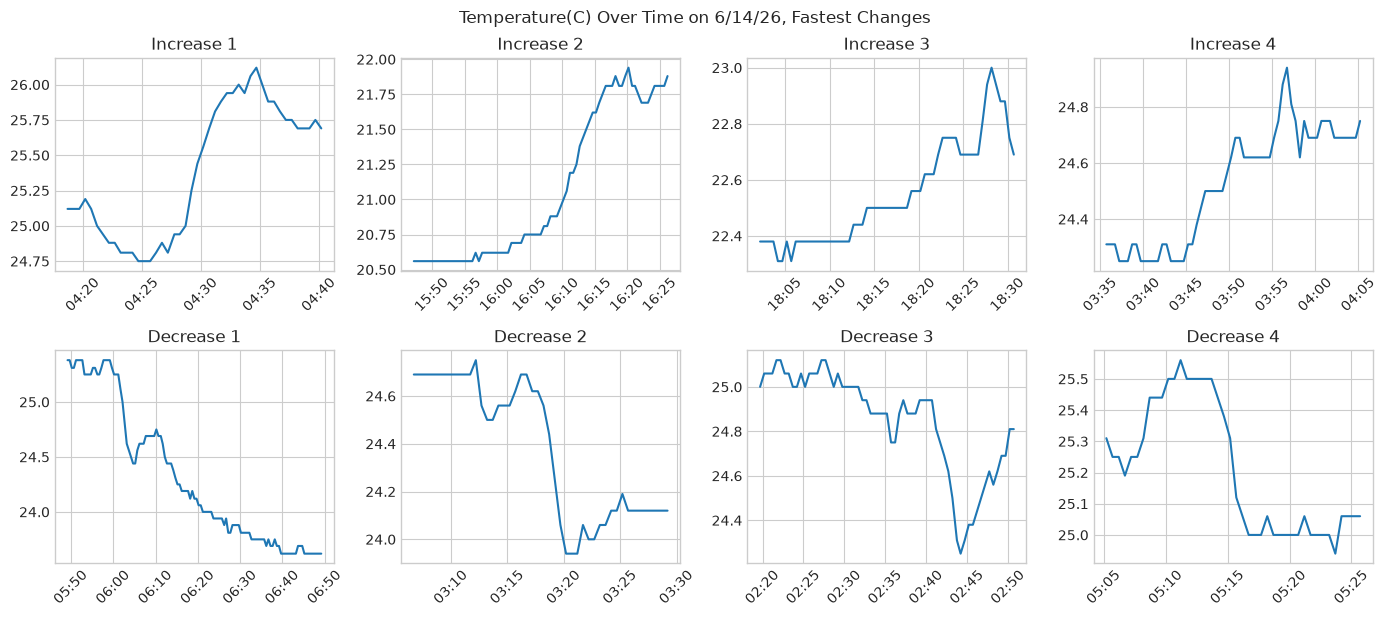

In [22]:
fig,ax = plt.subplots(2, len(to_plot_inc), figsize= (14,6))
#increasing --> top row
for i in range(len(to_plot_inc)):
    start = to_plot_inc[i][0]
    end = to_plot_inc[i][1]
    partial_df = df_long.iloc[start:end] #take the part of df_long that contains the increase
    ax[0][i].plot(partial_df.timestamp, partial_df.temperature_c)
    ax[0][i].set_title(f"Increase {i+1}")
#decreasing --> bottom row
for i in range(len(to_plot_dec)):
    start = to_plot_dec[i][0]
    end = to_plot_dec[i][1]
    partial_df = df_long.iloc[start:end] #take the part of df_long that contains the decrease
    ax[1][i].plot(partial_df.timestamp, partial_df.temperature_c)
    ax[1][i].set_title(f"Decrease {i+1}")

#fix time axis displays
for row in ax:
    for a in row:
        locator = mdates.AutoDateLocator()
        formatter = mdates.DateFormatter("%H:%M")
        a.xaxis.set_major_locator(locator)
        a.xaxis.set_major_formatter(formatter)
        plt.setp(a.get_xticklabels(), rotation=45, visible=True)
plt.tight_layout()
fig.suptitle('Temperature(C) Over Time on 6/14/26, Fastest Changes', y = 1.02)

#append current date & time ensure no overwriting
now = datetime.now()
file_name = OUTPUT_FILE_FOLDER + '/' + 'biggest_temperature_changes_6-14' + '-' + now.strftime('%m-%d-%y-%H-%M-%S') + '.png'
plt.savefig(file_name)

plt.show()

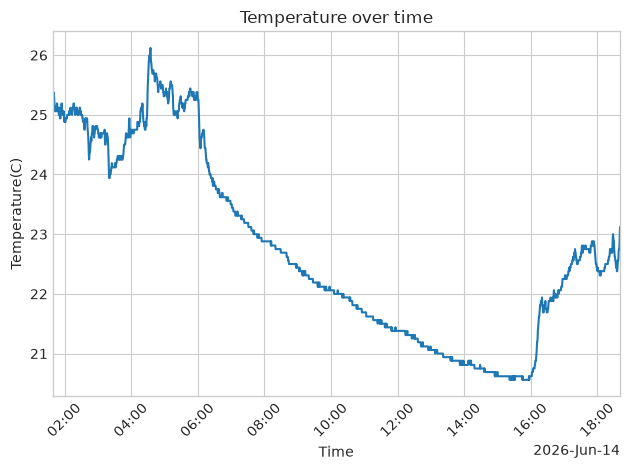

In [23]:
#let's look at the full graph of df_long again for reference
fig,ax = plt.subplots()

ax.plot(dfs[longest_index].timestamp, dfs[longest_index].temperature_c)

ax.set(
    title = 'Temperature over time',
    xlabel = 'Time',
    ylabel = 'Temperature(C)'
)

#fix time axis display
ax.tick_params(axis='x', rotation=45)
locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

plt.margins(x=0)
plt.tight_layout()

plt.show()